# Weight Initialization Methods

✅ The Weight Initializations features:

- Tests Glorot Uniform, He Normal, Lecun Normal, and Random Normal

- Trains CNNs on MNIST using each initializer

- Compares validation accuracy across initializers



## Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, initializers
import matplotlib.pyplot as plt

# Load dataset

In [ ]:
# Load dataset (MNIST)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Dictionary of different initializers
init_methods = {
    "Glorot Uniform": initializers.GlorotUniform(),
    "He Normal": initializers.HeNormal(),
    "Lecun Normal": initializers.LecunNormal(),
    "Random Normal": initializers.RandomNormal(mean=0.0, stddev=0.05),
}

# Create model

In [ ]:
# Function to create model with a specific initializer
def create_model(initializer):
    model = keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', kernel_initializer=initializer, input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu', kernel_initializer=initializer),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu', kernel_initializer=initializer),
        layers.Dense(10, activation='softmax')
    ])
    return model

# Train model

In [ ]:
# Train models using different initializers
histories = {}

for name, initializer in init_methods.items():
    print(f"Training model with {name} initializer")
    model = create_model(initializer)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_data=(x_test, y_test), verbose=1)
    histories[name] = history

Training model with Glorot Uniform initializer


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 52s 53ms/step - accuracy: 0.8939 - loss: 0.3568 - val_accuracy: 0.9861 - val_loss: 0.0414
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 45s 48ms/step - accuracy: 0.9847 - loss: 0.0505 - val_accuracy: 0.9876 - val_loss: 0.0346
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 48ms/step - accuracy: 0.9903 - loss: 0.0301 - val_accuracy: 0.9883 - val_loss: 0.0352
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.9918 - loss: 0.0257 - val_accuracy: 0.9910 - val_loss: 0.0254
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 46ms/step - accuracy: 0.9952 - loss: 0.0162 - val_accuracy: 0.9902 - val_loss: 0.0305
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 45s 48ms/step - accuracy: 0.9961 - loss: 0.0125 - val_accuracy: 0.9905 - val_loss: 0.0297
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 47ms/step - accuracy: 0.9967 - loss: 0.0109 - val_accuracy: 0.9895 - val_loss: 0.0349
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 47ms/step - accuracy: 0.9972 - loss: 0.0090 - 

# Plot validation accuracy

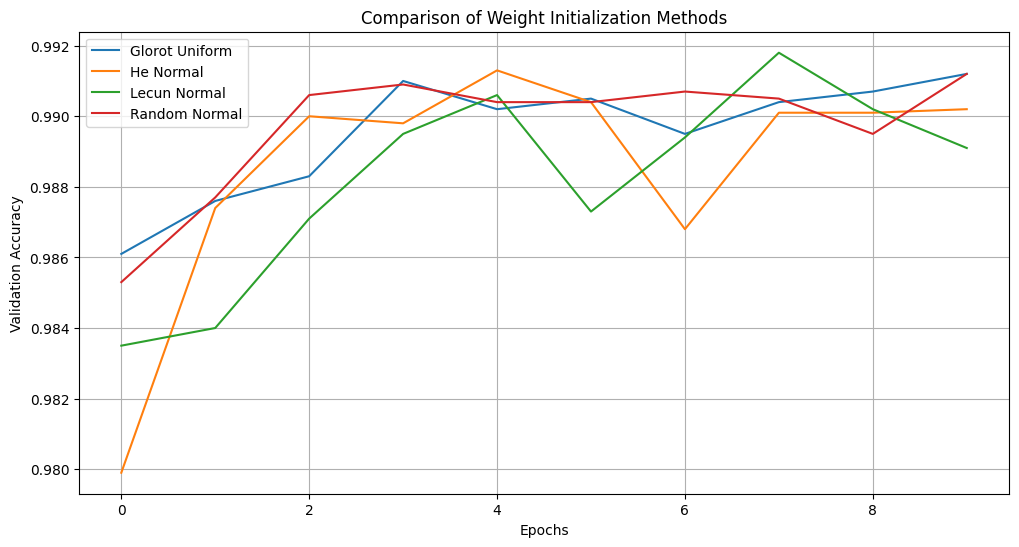

In [ ]:
# Plot validation accuracy for comparison
plt.figure(figsize=(12, 6))
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Comparison of Weight Initialization Methods')
plt.legend()
plt.grid(True)
plt.show()


Weight Initialization Methods

📘 Overview

This Colab notebook explores different weight initialization strategies in training a CNN model using Keras. Proper initialization can significantly affect training convergence, stability, and overall model performance.

🧪 Objective

To analyze and compare the impact of the following initializers:

- Glorot Uniform (a.k.a. Xavier Initialization)

- He Normal (for ReLU activations)

- Lecun Normal (for SELU activations)

- Random Normal (basic baseline)

🛠️ Implementation Details

Dataset: MNIST (handwritten digits)

Model Architecture:

Conv2D → MaxPooling

Conv2D → MaxPooling

Dense → Dense (Softmax)

Training Setup:

Epochs: 10

Batch Size: 64

Optimizer: Adam

Loss: Sparse Categorical Crossentropy

⚙️ Initialization Strategies

Initializer

Use Case

Glorot Uniform

Balanced for tanh/sigmoid activations

He Normal

Best for ReLU and its variants

Lecun Normal

Best for SELU/self-normalizing networks

Random Normal

Baseline; not optimized for deep nets

Each initializer is used to train a separate model, and results are compared using validation accuracy.

📈 Results

A plot shows validation accuracy across epochs for each method.

- Observations:

He Normal converges faster and performs best (ReLU-optimized).Glorot Uniform is stable and moderately effective.Random Normal is inconsistent.Lecun Normal is effective only with specific activations like SELU.

🧠 Insights

Choosing the right initializer depends on the activation function and depth of your model.

Bad initialization can lead to vanishing/exploding gradients or poor convergence.

Best practices:

- ReLU? ➤ Use He

- SELU? ➤ Use Lecun

- Sigmoid/tanh? ➤ Use Glorot